# FKIF — A Fuzzy Knowledge-Inference Framework for AI-Adoption Risk in Automotive SMEs

### Reproducible pipeline for the revised *IJSSCI* (IGI Global) manuscript

Run this notebook top to bottom. It regenerates **every number, table and figure** in the paper.

| Paper item | Produced by |
|---|---|
| Table 2 (rule base of $\mathcal{F}_1$) | Stage 2 |
| Table 3 (anchors and archetypes, all instruments) | Stage 5 |
| Table 4 (monotonicity) | Stage 7 |
| Table 5 (convergent validity, weighted kappa, bootstrap CIs) | Stage 6 |
| Table 6 (confusion matrix) | Stage 6 |
| Table 7 (sensitivity analysis) | Stage 9 |
| Rough-set core and $\gamma_C$ | Stage 8 |
| Figures 1–3 (600 dpi TIF) | Stage 10 |

**Scope statement.** This validates methodological convergence and formal behaviour, not empirical field accuracy. No primary human data are used. Primary expert elicitation and field validation are identified as future work.

**Seeds.** Evaluation population `seed=11`; monotonicity trials `seed=5` (replication) and `seed=2026` (fresh); rough-set decision table `seed=3`; bootstrap `seed=7`. Every reported statistic is deterministic.

In [2]:
# Stage 0 — environment
!pip -q install "scikit-fuzzy>=0.5" networkx scikit-learn scipy matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 4.0 MB/s eta 0:00:00


In [3]:
import sys, itertools, json
import numpy as np, pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from scipy.stats import spearmanr, kendalltau
from sklearn.metrics import cohen_kappa_score, confusion_matrix
import matplotlib; import matplotlib.pyplot as plt

FACTORS = ['tech_readiness','data_quality','financial','workforce','culture',
           'cybersecurity','regulatory','supply_integration']
ORDER   = {'Low':0,'Moderate':1,'High':2,'Critical':3}
LABELS  = list(ORDER)

print("python     ", sys.version.split()[0])
for m in (np, pd, fuzz, matplotlib):
    print(f"{m.__name__:11s}", m.__version__)

python      3.13.15
numpy       2.1.3
pandas      2.2.3
skfuzzy     0.5.0
matplotlib  3.10.0


## Stage 1 — Membership functions

Every factor carries three terms on the favorability domain $[0,10]$: `poor` = trapezoid $[0,0,2.5,4.5]$,
`moderate` = triangle $[3.5,5,6.5]$, `strong` = trapezoid $[5.5,7.5,10,10]$. The dimensional sub-risk
variables reuse the same three-term structure. The overall risk variable uses four terms on $[0,100]$.

These are a symmetric three-term partition with crossovers at the quartile boundaries and an overlap of
two units. They are **not** elicited from domain experts; Stage 9 tests how much the results depend on them.
The overlap is a well-formedness condition, not a style choice: a term system that leaves a gap admits
inputs for which no rule fires (demonstrated at the end of Stage 9).

In [4]:
# Membership breakpoints, exposed so Stage 9 can perturb them.
MF_DEFAULT = dict(poor_c=2.5, poor_d=4.5, mod_a=3.5, mod_b=5.0, mod_c=6.5, strong_a=5.5, strong_b=7.5)

def three_term(var, mf):
    var['poor']     = fuzz.trapmf(var.universe, [0, 0, mf['poor_c'], mf['poor_d']])
    var['moderate'] = fuzz.trimf (var.universe, [mf['mod_a'], mf['mod_b'], mf['mod_c']])
    var['strong']   = fuzz.trapmf(var.universe, [mf['strong_a'], mf['strong_b'], 10, 10])
    return var

def three_term_risk(var, mf):
    var['low']    = fuzz.trapmf(var.universe, [0, 0, mf['poor_c'], mf['poor_d']])
    var['medium'] = fuzz.trimf (var.universe, [mf['mod_a'], mf['mod_b'], mf['mod_c']])
    var['high']   = fuzz.trapmf(var.universe, [mf['strong_a'], mf['strong_b'], 10, 10])
    return var

## Stage 2 — Rule generation schema and the level-1 sub-systems

The rule bases are **not hand-assembled**. Every rule is the image of a deterministic severity schema, so the
whole inference system follows from a few stated parameters and can be audited without reading this code.

For a sub-system with $k$ inputs, assign $\lambda(\text{poor})=2$, $\lambda(\text{moderate})=1$,
$\lambda(\text{strong})=0$. For a term combination $c$ the normalized severity is

$$\sigma(c) = \frac{1}{2k}\sum_{i=1}^{k}\lambda(c_i) \in [0,1],$$

and the consequent is `low` if $\sigma < 0.34$, `medium` if $0.34 \le \sigma < 0.67$, `high` otherwise.
The thresholds sit marginally above the equal-thirds points $1/3$ and $2/3$, so a combination whose severity
falls exactly on a third resolves into the **lower** risk class. This only bites for the three-input
organizational sub-system, where $\sigma$ can equal $1/3$ or $2/3$ exactly.

Applied to the full Cartesian product this makes each rule base *complete* by construction, *consistent*
because $\sigma$ is a function of the term combination, and *monotone* because $\sigma$ is non-decreasing in
each $\lambda(c_i)$ and the threshold map is a non-decreasing step function.

In [5]:
LEVEL1_SEVERITY  = {'poor':2, 'moderate':1, 'strong':0}
LEVEL1_THRESHOLDS = (0.34, 0.67)        # marginally above the equal-thirds points 1/3 and 2/3

def level1_consequent(combo, thr=LEVEL1_THRESHOLDS):
    k = len(combo)
    sigma = sum(LEVEL1_SEVERITY[t] for t in combo) / (2*k)
    term  = 'low' if sigma < thr[0] else ('medium' if sigma < thr[1] else 'high')
    return sigma, term

def make_sub(inputs, out_name, mf=None, thr=LEVEL1_THRESHOLDS, istep=0.1):
    mf = mf or MF_DEFAULT
    ants = {n: three_term(ctrl.Antecedent(np.arange(0, 10.01, istep), n), mf) for n in inputs}
    cons = three_term_risk(ctrl.Consequent(np.arange(0, 10.01, istep), out_name), mf)
    rules = []
    for combo in itertools.product(['poor','moderate','strong'], repeat=len(inputs)):
        _, term = level1_consequent(combo, thr)
        ante = None
        for n, t in zip(inputs, combo):
            ante = ants[n][t] if ante is None else ante & ants[n][t]
        rules.append(ctrl.Rule(ante, cons[term]))
    return ctrl.ControlSystem(rules)

def run_sub(system, out_name, **values):
    sim = ctrl.ControlSystemSimulation(system)
    for k, v in values.items():
        sim.input[k] = v
    sim.compute()
    return sim.output[out_name]

In [6]:
# ---- Table 2 of the paper: rule base of the technical-capability sub-system ----
rows = []
for i, combo in enumerate(itertools.product(['poor','moderate','strong'], repeat=2), start=1):
    sigma, term = level1_consequent(combo)
    rows.append({'#': i, 'Technological readiness': combo[0], 'Data quality': combo[1],
                 'sigma': round(sigma, 2), 'Technical sub-risk': term})
TABLE2 = pd.DataFrame(rows)
print("TABLE 2 — rule base of F1 (generated, not hand-written)")
print(TABLE2.to_string(index=False))

TABLE 2 — rule base of F1 (generated, not hand-written)
 # Technological readiness Data quality  sigma Technical sub-risk
 1                    poor         poor   1.00               high
 2                    poor     moderate   0.75               high
 3                    poor       strong   0.50             medium
 4                moderate         poor   0.75               high
 5                moderate     moderate   0.50             medium
 6                moderate       strong   0.25                low
 7                  strong         poor   0.50             medium
 8                  strong     moderate   0.25                low
 9                  strong       strong   0.00                low


## Stage 3 — Level-2 aggregation: anchored, compliance-weighted, non-compensatory

Same severity construction with $\lambda(\text{low})=0,\lambda(\text{medium})=1,\lambda(\text{high})=2$,
weight vector $w=(1.0,\,1.0,\,1.5,\,0.7)$ and three thresholds, followed by the compliance veto.

**The veto has no threshold parameter of its own.** It engages exactly when the `high` term of the security
sub-risk fires, and that term is the trapezoid $[5.5,7.5,10,10]$ shared by all four sub-risk variables. The
escalation point is a consequence of the term system, not an extra degree of freedom. It is applied when the
*consequent term of each rule* is assigned, not as a post-hoc correction to the crisp index.

**Anchor admissibility.** Requiring all-low → Low, all-medium → Moderate, all-high → Critical constrains the
thresholds to $0 < t_1 \le 0.5 < t_2 \le t_3 \le 1$. Verified numerically at the end of this stage.

In [7]:
LEVEL2_SEVERITY = {'low':0, 'medium':1, 'high':2}
RANK = ['low','moderate','high','critical']

def level2_consequent(combo, w, thr, veto=True):
    sigma = sum(LEVEL2_SEVERITY[combo[i]] * w[i] for i in range(4)) / (2*sum(w))
    cl = ('low' if sigma < thr[0] else 'moderate' if sigma < thr[1]
          else 'high' if sigma < thr[2] else 'critical')
    if veto and combo[2] == 'high':                       # index 2 = security/compliance
        cl = RANK[max(RANK.index(cl), 2)]                 # at least High
        if 'high' in (combo[0], combo[1], combo[3]):      # plus a second weakness
            cl = 'critical'
    return sigma, cl

OUT_MF = dict(low=[0,0,18,32], moderate=[26,42,60], high=[52,68,84], critical=[78,90,100,100])

def build_agg(w_sec=1.5, w_eco=0.7, thr=(0.28,0.58,0.82), veto=True, ostep=0.5, astep=0.1):
    # astep is the aggregation ANTECEDENT resolution and stays fixed; ostep is the
    # level-2 defuzzification grid, which the Stage 7 refinement test varies.
    names = ['tech_risk','org_risk','sec_risk','eco_risk']
    ants = {}
    for n in names:
        v = ctrl.Antecedent(np.arange(0, 10.01, astep), n)
        ants[n] = three_term_risk(v, MF_DEFAULT)
    out = ctrl.Consequent(np.arange(0, 100.01, ostep), 'overall_risk')
    out['low']      = fuzz.trapmf(out.universe, OUT_MF['low'])
    out['moderate'] = fuzz.trimf (out.universe, OUT_MF['moderate'])
    out['high']     = fuzz.trimf (out.universe, OUT_MF['high'])
    out['critical'] = fuzz.trapmf(out.universe, OUT_MF['critical'])
    w = [1.0, 1.0, w_sec, w_eco]
    rules = []
    for combo in itertools.product(['low','medium','high'], repeat=4):
        _, cl = level2_consequent(combo, w, thr, veto)
        rules.append(ctrl.Rule(ants['tech_risk'][combo[0]] & ants['org_risk'][combo[1]] &
                               ants['sec_risk'][combo[2]] & ants['eco_risk'][combo[3]], out[cl]))
    return ctrl.ControlSystem(rules)

CLASS_BOUNDS = (30, 55, 80)
def band(x, b=CLASS_BOUNDS):
    return 'Low' if x < b[0] else ('Moderate' if x < b[1] else ('High' if x < b[2] else 'Critical'))

In [8]:
class FKIF:
    """Two-stage rough-fuzzy AI-adoption risk framework. Every design parameter is a named argument,
    so each Stage 9 sensitivity variant changes one argument rather than editing the model."""
    def __init__(self, mf=None, thr1=LEVEL1_THRESHOLDS, w_sec=1.5, w_eco=0.7,
                 thr2=(0.28,0.58,0.82), veto=True, ostep=0.5, istep=0.1):
        mf = mf or MF_DEFAULT
        self.tech = make_sub(['tech_readiness','data_quality'],        'tech_risk', mf, thr1, istep)
        self.org  = make_sub(['financial','workforce','culture'],      'org_risk',  mf, thr1, istep)
        self.sec  = make_sub(['cybersecurity','regulatory'],           'sec_risk',  mf, thr1, istep)
        self.eco  = make_sub(['supply_integration'],                   'eco_risk',  mf, thr1, istep)
        self.agg  = build_agg(w_sec, w_eco, thr2, veto, ostep)

    def subrisks(self, p):
        return (run_sub(self.tech,'tech_risk', tech_readiness=p[0], data_quality=p[1]),
                run_sub(self.org ,'org_risk',  financial=p[2], workforce=p[3], culture=p[4]),
                run_sub(self.sec ,'sec_risk',  cybersecurity=p[5], regulatory=p[6]),
                run_sub(self.eco ,'eco_risk',  supply_integration=p[7]))

    def aggregate(self, sub):
        sim = ctrl.ControlSystemSimulation(self.agg)
        for n, v in zip(['tech_risk','org_risk','sec_risk','eco_risk'], sub):
            sim.input[n] = v
        sim.compute()
        return sim.output['overall_risk']

    def __call__(self, p):
        return self.aggregate(self.subrisks(p))

fkif = FKIF()
print("ANCHORS")
for nm, v in [('all-strong',8), ('all-moderate',5), ('all-poor',2)]:
    x = fkif([v]*8); print(f"  {nm:14s} {x:6.2f}  ({band(x)})")
x = fkif([8,8,8,8,8,2,2,8]); print(f"  strong/weak-compliance {x:6.2f}  ({band(x)})   <- veto")

ANCHORS
  all-strong      12.83  (Low)
  all-moderate    42.67  (Moderate)
  all-poor        91.62  (Critical)
  strong/weak-compliance  68.00  (High)   <- veto


In [9]:
# ---- anchor-admissible region for the level-2 thresholds ----
w = [1.0, 1.0, 1.5, 0.7]
sev = lambda c: sum(LEVEL2_SEVERITY[c[i]]*w[i] for i in range(4)) / (2*sum(w))
realised = sorted({round(sev(c), 6) for c in itertools.product(['low','medium','high'], repeat=4)})
print(f"sigma(all-low)={sev(('low',)*4):.3f}  sigma(all-medium)={sev(('medium',)*4):.3f}  "
      f"sigma(all-high)={sev(('high',)*4):.3f}")
print(f"distinct severity values realised by the 81 aggregation rules: {len(realised)}")
print("anchor constraint: 0 < t1 <= 0.5 < t2 <= t3 <= 1   |   chosen (0.28, 0.58, 0.82) -> inside")
print("rule base is a step function of the thresholds, so it is invariant to any movement")
print("between two adjacent realised values.")

sigma(all-low)=0.000  sigma(all-medium)=0.500  sigma(all-high)=1.000
distinct severity values realised by the 81 aggregation rules: 39
anchor constraint: 0 < t1 <= 0.5 < t2 <= t3 <= 1   |   chosen (0.28, 0.58, 0.82) -> inside
rule base is a step function of the thresholds, so it is invariant to any movement
between two adjacent realised values.


## Stage 4 — Four reference instruments and the evaluation population

References A and B are compensatory. A comparison restricted to compensatory references cannot distinguish
FKIF from any instrument that is simply *more severe*, so we add two more: C is a fully non-compensatory
bottleneck, D a partially compensatory geometric mean. The four span the compensatory spectrum.

Uniformly random profiles are unsuitable: they do not resemble real firms, and they make bottleneck
instruments pathological because a random 8-D profile almost always contains one very low value. We use a
correlated latent-maturity population instead.

In [10]:
def ref_A_schumacher(p):                      # weighted-mean Industry 4.0 maturity
    maturity = 1 + np.asarray(p)/10*4
    wts = np.array([0.16,0.12,0.12,0.14,0.10,0.12,0.14,0.10])
    s = float(np.dot(wts, maturity))
    return 'Low' if s>=4 else ('Moderate' if s>=3 else ('High' if s>=2 else 'Critical'))

def ref_B_toe(p):                             # TOE composite
    T = np.mean([p[0],p[1]]); O = np.mean([p[2],p[3],p[4]]); E = np.mean([p[5],p[6],p[7]])
    m = float(np.mean([T,O,E]))
    return 'Low' if m>=6.5 else ('Moderate' if m>=4 else ('High' if m>=2.5 else 'Critical'))

def ref_C_bottleneck(p):                      # fully non-compensatory
    m = float(np.min(p))
    return 'Low' if m>=6.5 else ('Moderate' if m>=4.5 else ('High' if m>=2.5 else 'Critical'))

def ref_D_geomean(p):                         # partially compensatory
    g = float(np.exp(np.mean(np.log(np.asarray(p, dtype=float)))))
    return 'Low' if g>=6.5 else ('Moderate' if g>=4.5 else ('High' if g>=2.5 else 'Critical'))

def crisp_baseline(p):                        # equal-weight linear
    return round((10 - float(np.mean(p))) * 10, 1)

REFS = {'A Schumacher (compensatory)':      ref_A_schumacher,
        'B TOE composite (compensatory)':   ref_B_toe,
        'C Bottleneck (non-compensatory)':  ref_C_bottleneck,
        'D Geometric mean (partial)':       ref_D_geomean}

def population(seed=11, N=400):
    rng = np.random.default_rng(seed); out = []
    for _ in range(N):
        m = rng.uniform(1, 10)
        p = np.clip(np.round(m + rng.normal(0, 1.0, 8)), 1, 10).astype(int)
        if rng.random() < 0.30:                                  # one weakened dimension
            dim = rng.integers(0, 4)
            for i in [[0,1],[2,3,4],[5,6],[7]][dim]:
                p[i] = int(np.clip(p[i] - rng.integers(3, 6), 1, 10))
        out.append(p)
    return np.array(out)

PROFILES = population()
print("evaluation population:", PROFILES.shape)

evaluation population: (400, 8)


## Stage 5 — Table 3: anchor calibration and archetype face validity

The informative row is the last one. A technically strong supplier with weak compliance is **High** under
FKIF, **Moderate** under both compensatory references and the geometric mean, and **Critical** under the
bottleneck. FKIF is *selectively* non-compensatory: it escalates because compliance is weak, but does not go
to Critical as a bottleneck would, because the weakness sits in one dimension.

In [11]:
ANCHORS = {'Uniformly strong (all 8)':   [8]*8,
           'Uniformly moderate (all 5)': [5]*8,
           'Uniformly poor (all 2)':     [2]*8}
ARCHETYPES = {'Digitally mature niche manufacturer': [8,8,7,8,7,8,8,7],
              'Mid-maturity tier-2 supplier':        [5,5,5,5,5,5,5,5],
              'Low-maturity traditional SME':        [2,2,3,2,3,2,2,3],
              'Strong technical, weak compliance':   [8,8,7,7,7,2,2,6]}

rows = []
for name, p in {**ANCHORS, **ARCHETYPES}.items():
    x = fkif(p)
    rows.append({'Profile': name, 'FKIF index': round(x,1), 'FKIF class': band(x),
                 'Crisp': crisp_baseline(p),
                 **{k.split()[0]: f(p) for k, f in REFS.items()}})
TABLE3 = pd.DataFrame(rows)
print("TABLE 3")
print(TABLE3.to_string(index=False))

TABLE 3
                            Profile  FKIF index FKIF class  Crisp        A        B        C        D
           Uniformly strong (all 8)        12.8        Low   20.0      Low      Low      Low      Low
         Uniformly moderate (all 5)        42.7   Moderate   50.0 Moderate Moderate Moderate Moderate
             Uniformly poor (all 2)        91.6   Critical   80.0 Critical Critical Critical Critical
Digitally mature niche manufacturer        12.8        Low   23.8      Low      Low      Low      Low
       Mid-maturity tier-2 supplier        42.7   Moderate   50.0 Moderate Moderate Moderate Moderate
       Low-maturity traditional SME        91.6   Critical   76.2 Critical Critical Critical Critical
  Strong technical, weak compliance        68.0       High   41.2 Moderate Moderate Critical Moderate


## Stage 6 — Tables 5 and 6: convergent validity

Unweighted Cohen's $\kappa$ treats a Low-vs-Critical disagreement the same as Low-vs-Moderate, which is the
wrong statistic for an ordered four-class scale. We report **weighted** $\kappa$ (Cohen, 1968) as the primary
class-agreement measure, with bootstrap confidence intervals, and keep unweighted $\kappa$ for transparency.

The class marginals printed at the end are the mechanism behind the low unweighted values: FKIF populates
Moderate an order of magnitude less densely than either compensatory reference. This is the documented
prevalence paradox (Feinstein & Cicchetti, 1990; Byrt, Bishop & Carlin, 1993), not poor agreement.

In [12]:
FV = np.array([fkif(p) for p in PROFILES])
FB = np.array([band(x) for x in FV])
REF_LABELS = {k: np.array([f(p) for p in PROFILES]) for k, f in REFS.items()}

def bootstrap_ci(a, b, stat, B=2000, seed=7):
    rng = np.random.default_rng(seed); n = len(a); vals = []
    a = np.asarray(a); b = np.asarray(b)
    for _ in range(B):
        idx = rng.integers(0, n, n)
        try: vals.append(stat(a[idx], b[idx]))
        except Exception: pass
    return np.percentile(vals, [2.5, 97.5])

rows = []
for name, rb in REF_LABELS.items():
    ro = np.array([ORDER[x] for x in rb]); fo = np.array([ORDER[x] for x in FB])
    rho = spearmanr(FV, ro).statistic
    k   = cohen_kappa_score(FB, rb, labels=LABELS)
    kl  = cohen_kappa_score(FB, rb, labels=LABELS, weights='linear')
    kq  = cohen_kappa_score(FB, rb, labels=LABELS, weights='quadratic')
    ci_rho = bootstrap_ci(FV, ro, lambda x,y: spearmanr(x,y).statistic)
    ci_k   = bootstrap_ci(FB, rb, lambda x,y: cohen_kappa_score(x,y,labels=LABELS))
    ci_kl  = bootstrap_ci(FB, rb, lambda x,y: cohen_kappa_score(x,y,labels=LABELS,weights='linear'))
    ci_kq  = bootstrap_ci(FB, rb, lambda x,y: cohen_kappa_score(x,y,labels=LABELS,weights='quadratic'))
    rows.append({'Comparison': f'FKIF vs {name}',
                 'Spearman rho': f"{rho:.3f} [{ci_rho[0]:.3f}, {ci_rho[1]:.3f}]",
                 'Kendall tau_b': f"{kendalltau(FV, ro).statistic:.3f}",
                 'kappa': f"{k:.3f} [{ci_k[0]:.3f}, {ci_k[1]:.3f}]",
                 'kappa (linear)': f"{kl:.3f} [{ci_kl[0]:.3f}, {ci_kl[1]:.3f}]",
                 'kappa (quadratic)': f"{kq:.3f} [{ci_kq[0]:.3f}, {ci_kq[1]:.3f}]",
                 'Exact': f"{np.mean(fo==ro):.1%}", 'Within one band': f"{np.mean(np.abs(fo-ro)<=1):.1%}"})

rs, rt = REF_LABELS['A Schumacher (compensatory)'], REF_LABELS['B TOE composite (compensatory)']
so, to = np.array([ORDER[x] for x in rs]), np.array([ORDER[x] for x in rt])
rows.append({'Comparison':'Ref. A vs Ref. B',
             'Spearman rho': f"{spearmanr(so,to).statistic:.3f}", 'Kendall tau_b':'n/a',
             'kappa': f"{cohen_kappa_score(rs,rt,labels=LABELS):.3f}",
             'kappa (linear)': f"{cohen_kappa_score(rs,rt,labels=LABELS,weights='linear'):.3f}",
             'kappa (quadratic)': f"{cohen_kappa_score(rs,rt,labels=LABELS,weights='quadratic'):.3f}",
             'Exact': f"{np.mean(so==to):.1%}", 'Within one band': f"{np.mean(np.abs(so-to)<=1):.1%}"})
TABLE5 = pd.DataFrame(rows)
print("TABLE 5"); print(TABLE5.to_string(index=False))

TABLE 5
                             Comparison         Spearman rho Kendall tau_b                kappa       kappa (linear)    kappa (quadratic) Exact Within one band
    FKIF vs A Schumacher (compensatory) 0.886 [0.866, 0.905]         0.802 0.295 [0.248, 0.346] 0.599 [0.559, 0.639] 0.801 [0.771, 0.828] 44.8%           98.0%
 FKIF vs B TOE composite (compensatory) 0.889 [0.866, 0.910]         0.808 0.378 [0.325, 0.430] 0.617 [0.572, 0.661] 0.778 [0.740, 0.813] 54.0%           91.0%
FKIF vs C Bottleneck (non-compensatory) 0.838 [0.799, 0.873]         0.753 0.400 [0.348, 0.454] 0.585 [0.534, 0.636] 0.710 [0.656, 0.760] 56.5%           85.8%
     FKIF vs D Geometric mean (partial) 0.897 [0.872, 0.916]         0.817 0.430 [0.377, 0.486] 0.680 [0.636, 0.721] 0.834 [0.801, 0.864] 58.5%           95.2%
                       Ref. A vs Ref. B                0.922           n/a                0.676                0.799                0.895 75.8%          100.0%


In [13]:
print("TABLE 6 — confusion matrix, Reference A (rows) vs FKIF (columns)")
TABLE6 = pd.DataFrame(confusion_matrix(rs, FB, labels=LABELS),
                      index=[f'Ref A {k}' for k in LABELS], columns=[f'FKIF {k}' for k in LABELS])
print(TABLE6.to_string())

print("\nClass marginals (N=400) — the mechanism behind the low unweighted kappa:")
MARGINALS = pd.DataFrame({'FKIF':  pd.Series(FB).value_counts().reindex(LABELS).fillna(0).astype(int),
                          'Ref A': pd.Series(rs).value_counts().reindex(LABELS).fillna(0).astype(int),
                          'Ref B': pd.Series(rt).value_counts().reindex(LABELS).fillna(0).astype(int)})
print(MARGINALS.to_string())

TABLE 6 — confusion matrix, Reference A (rows) vs FKIF (columns)
                FKIF Low  FKIF Moderate  FKIF High  FKIF Critical
Ref A Low             90              0          3              0
Ref A Moderate        89              6         14              1
Ref A High             4             11         13             99
Ref A Critical         0              0          0             70

Class marginals (N=400) — the mechanism behind the low unweighted kappa:
          FKIF  Ref A  Ref B
Low        183     93    142
Moderate    17    110    106
High        30    127     85
Critical   170     70     67


## Stage 7 — Table 4: monotonicity, and why the residual is *not* a discretisation artifact

Proposition 1 in the paper establishes monotonicity of the **rule-consequent map** exactly. It does not
follow that the crisp index is monotone, because sup–min composition with centroid defuzzification does not
preserve rule-base monotonicity (Van Broekhoven & De Baets, 2009), and min–max composition does not carry
the property through a hierarchy (Kouikoglou & Phillis, 2009).

Three checks below, in order:

1. **Grid refinement.** Refining the output universe 1.0 → 0.05 and the sub-risk universes 0.1 → 0.02 leaves
   the violation count and magnitude unchanged. The residual is therefore structural, **not** numerical.
2. **Magnitude and class invariance** across three perturbation sizes at a fresh seed.
3. **Pareto dominance** over every comparable pair in the evaluation population.

The operationally relevant property — that the assigned *class* never moves the wrong way — holds in every
test. Cell 3 takes a few minutes.

In [14]:
def monotonicity_trial(model, n=400, delta=2, seed=5):
    rng = np.random.default_rng(seed); viol = []; class_viol = 0
    for _ in range(n):
        p = rng.integers(1, 10, size=8); j = rng.integers(0, 8)
        q = p.copy(); q[j] = min(10, p[j] + delta)
        a, b = model(p), model(q)
        if b > a + 1e-6:
            viol.append(b - a)
            if ORDER[band(b)] > ORDER[band(a)]: class_viol += 1
    d = np.array(viol) if viol else np.array([0.0])
    return dict(trials=n, violations=len(viol), rate=len(viol)/n,
                max_mag=float(d.max()), mean_mag=float(d.mean()), class_violations=class_viol)

print("CHECK 1 — grid refinement (are the violations numerical?)")
for ostep, istep in [(1.0,0.1), (0.5,0.1), (0.25,0.05), (0.1,0.02)]:
    r = monotonicity_trial(FKIF(ostep=ostep, istep=istep), seed=5)
    print(f"  output grid {ostep:<5} sub-risk grid {istep:<5} -> "
          f"satisfied {1-r['rate']:6.1%}, n={r['violations']:2d}, max={r['max_mag']:.4f}")
print("  => count and magnitude are invariant to grid refinement: the residual is STRUCTURAL.")

CHECK 1 — grid refinement (are the violations numerical?)
  output grid 1.0   sub-risk grid 0.1   -> satisfied  97.2%, n=11, max=0.9982
  output grid 0.5   sub-risk grid 0.1   -> satisfied  97.2%, n=11, max=0.9982
  output grid 0.25  sub-risk grid 0.05  -> satisfied  97.2%, n=11, max=0.9981
  output grid 0.1   sub-risk grid 0.02  -> satisfied  97.2%, n=11, max=0.9980
  => count and magnitude are invariant to grid refinement: the residual is STRUCTURAL.


In [15]:
print("CHECK 2 — magnitude and class invariance (fresh seed 2026)")
rows = []
for delta in (1, 2, 3):
    r = monotonicity_trial(fkif, n=600, delta=delta, seed=2026)
    rows.append({'Test': f'Single-factor increase of +{delta}', 'Trials': r['trials'],
                 'Index-order violations': r['violations'], 'Rate': f"{r['rate']:.2%}",
                 'Max magnitude (index units)': round(r['max_mag'],2),
                 'Class-order violations': r['class_violations']})
r = monotonicity_trial(fkif, n=400, delta=2, seed=5)
rows.append({'Test': 'Original protocol, +2, seed 5', 'Trials': r['trials'],
             'Index-order violations': r['violations'], 'Rate': f"{r['rate']:.2%}",
             'Max magnitude (index units)': round(r['max_mag'],2),
             'Class-order violations': r['class_violations']})
for row in rows: print(" ", row)

CHECK 2 — magnitude and class invariance (fresh seed 2026)
  {'Test': 'Single-factor increase of +1', 'Trials': 600, 'Index-order violations': 21, 'Rate': '3.50%', 'Max magnitude (index units)': 1.25, 'Class-order violations': 0}
  {'Test': 'Single-factor increase of +2', 'Trials': 600, 'Index-order violations': 20, 'Rate': '3.33%', 'Max magnitude (index units)': 1.25, 'Class-order violations': 0}
  {'Test': 'Single-factor increase of +3', 'Trials': 600, 'Index-order violations': 26, 'Rate': '4.33%', 'Max magnitude (index units)': 1.25, 'Class-order violations': 0}
  {'Test': 'Original protocol, +2, seed 5', 'Trials': 400, 'Index-order violations': 11, 'Rate': '2.75%', 'Max magnitude (index units)': 1.0, 'Class-order violations': 0}


In [16]:
print("CHECK 3 — Pareto dominance over the evaluation population")
dom = bad = badclass = 0; worst = 0.0
for i in range(len(PROFILES)):
    gi = PROFILES[i]
    for k in range(len(PROFILES)):
        if i == k: continue
        if np.all(gi >= PROFILES[k]) and np.any(gi > PROFILES[k]):
            dom += 1
            if FV[i] > FV[k] + 1e-6:
                bad += 1; worst = max(worst, FV[i] - FV[k])
                if ORDER[band(FV[i])] > ORDER[band(FV[k])]: badclass += 1
print(f"  comparable ordered pairs        : {dom}")
print(f"  index-order violations          : {bad} ({bad/max(dom,1):.4%}), max excess {worst:.4f}")
print(f"  class-order violations          : {badclass}")
rows.append({'Test': 'Pareto dominance over evaluation population', 'Trials': f'{dom} pairs',
             'Index-order violations': bad, 'Rate': f"{bad/max(dom,1):.2%}",
             'Max magnitude (index units)': round(worst,2), 'Class-order violations': badclass})
TABLE4 = pd.DataFrame(rows)
print("\nTABLE 4"); print(TABLE4.to_string(index=False))

CHECK 3 — Pareto dominance over the evaluation population
  comparable ordered pairs        : 48023
  index-order violations          : 60 (0.1249%), max excess 1.2468
  class-order violations          : 0

TABLE 4
                                       Test      Trials  Index-order violations  Rate  Max magnitude (index units)  Class-order violations
               Single-factor increase of +1         600                      21 3.50%                         1.25                       0
               Single-factor increase of +2         600                      20 3.33%                         1.25                       0
               Single-factor increase of +3         600                      26 4.33%                         1.25                       0
              Original protocol, +2, seed 5         400                      11 2.75%                         1.00                       0
Pareto dominance over evaluation population 48023 pairs                      60 0.12%     

In [17]:
# Where does the residual originate? The level-1 sub-system is itself slightly non-monotone.
gx = np.arange(0, 10.01, 0.25)
Z  = np.array([[run_sub(fkif.tech,'tech_risk', tech_readiness=a, data_quality=b) for b in gx] for a in gx]).T
bad = []
for i in range(Z.shape[0]):
    for j in range(Z.shape[1]-1):
        if Z[i,j+1] > Z[i,j] + 1e-9: bad.append(Z[i,j+1]-Z[i,j])
for j in range(Z.shape[1]):
    for i in range(Z.shape[0]-1):
        if Z[i+1,j] > Z[i,j] + 1e-9: bad.append(Z[i+1,j]-Z[i,j])
print(f"level-1 technical sub-system: {len(bad)} grid-adjacent violations, "
      f"max magnitude {max(bad):.4f} on a sub-risk range of {Z.min():.2f} to {Z.max():.2f}")
print("=> the residual originates at level 1 and propagates; it is not introduced by the aggregation.")

level-1 technical sub-system: 220 grid-adjacent violations, max magnitude 0.0774 on a sub-risk range of 1.80 to 8.20
=> the residual originates at level 1 and propagates; it is not introduced by the aggregation.


## Stage 8 — Rough-set core: non-redundancy of the taxonomy

This establishes **non-redundancy, not dimensionality reduction**, and it delivers no computational economy:
the reduct is the full taxonomy, so nothing is removed and the rule count is unchanged.

The value of the stage is evidential. The eight factors came from a literature review, and a reader is
entitled to ask whether some are decorative. The analysis answers that against an *external* decision
standard (the Reference A label, not FKIF's own output), and it could have returned a smaller reduct.

Because the core equals $C$ and every reduct contains the core, $C$ is the **unique** reduct — no search
is required.

In [18]:
CENTROIDS = [[8,8,7,8,7,8,8,7], [6,6,5,6,6,5,6,6], [5,5,4,4,5,5,4,5],
             [3,4,3,3,4,3,3,4], [2,2,3,2,3,2,2,3], [7,7,3,4,4,2,2,6]]
coarse = lambda x: 'L' if x <= 4 else ('M' if x <= 7 else 'H')

rng = np.random.default_rng(3); rows = []
for _ in range(180):
    c = CENTROIDS[rng.integers(0, len(CENTROIDS))]
    p = np.clip(np.round(np.array(c) + rng.normal(0, 0.8, 8)), 1, 10).astype(int)
    rows.append({**{f: coarse(p[j]) for j, f in enumerate(FACTORS)}, 'RISK': ref_A_schumacher(p)})
DT = pd.DataFrame(rows)

def equivalence_classes(df, attrs):
    g = {}
    for i, r in df.iterrows(): g.setdefault(tuple(r[a] for a in attrs), []).append(i)
    return list(g.values())

def gamma(df, attrs, d='RISK'):
    if not attrs: return 0.0
    return sum(len(c) for c in equivalence_classes(df, attrs) if df.loc[c, d].nunique() == 1) / len(df)

g_full = gamma(DT, FACTORS)
core   = [a for a in FACTORS if gamma(DT, [x for x in FACTORS if x != a]) < g_full - 1e-9]
print(f"distinct coarse rows : {len(equivalence_classes(DT, FACTORS))} of {len(DT)}")
print(f"gamma_C              : {g_full:.3f}")
print(f"CORE (indispensable) : {len(core)} of 8 -> {core}")
print(f"dispensable          : {[f for f in FACTORS if f not in core]}")
print("\nper-factor gamma on removal (contribution of each factor):")
for a in FACTORS:
    print(f"  drop {a:20s} gamma = {gamma(DT, [x for x in FACTORS if x != a]):.3f}")
if len(core) == 8:
    print("\ncore == C, therefore C is the unique reduct (every reduct contains the core).")

distinct coarse rows : 79 of 180
gamma_C              : 0.650
CORE (indispensable) : 8 of 8 -> ['tech_readiness', 'data_quality', 'financial', 'workforce', 'culture', 'cybersecurity', 'regulatory', 'supply_integration']
dispensable          : []

per-factor gamma on removal (contribution of each factor):
  drop tech_readiness       gamma = 0.628
  drop data_quality         gamma = 0.572
  drop financial            gamma = 0.606
  drop workforce            gamma = 0.539
  drop culture              gamma = 0.600
  drop cybersecurity        gamma = 0.639
  drop regulatory           gamma = 0.572
  drop supply_integration   gamma = 0.622

core == C, therefore C is the unique reduct (every reduct contains the core).


## Stage 9 — Table 7: sensitivity and robustness

Every design parameter is perturbed one at a time. For each variant we report Spearman correlation with the
baseline index, the proportion of the 400 profiles keeping their baseline class, whether the anchors survive,
and the verdict on the strong-technical / weak-compliance archetype.

Aggregation-only variants reuse the cached level-1 sub-risks, so they run in seconds. Membership variants
require a full recomputation and take a few minutes.

In [19]:
SUB = np.array([fkif.subrisks(p) for p in PROFILES])                 # cache level-1 output
ARCH_SUB = np.array([fkif.subrisks(p) for p in ARCHETYPES.values()])
BASE_BANDS = FB.copy()
ro_A = np.array([ORDER[x] for x in rs])

def aggregate_only(sub_matrix, **kw):
    system = build_agg(**kw); out = []
    for row in sub_matrix:
        sim = ctrl.ControlSystemSimulation(system)
        for n, v in zip(['tech_risk','org_risk','sec_risk','eco_risk'], row): sim.input[n] = v
        sim.compute(); out.append(sim.output['overall_risk'])
    return np.array(out)

def summarise(name, values, arch_values):
    vb = np.array([band(x) for x in values])
    return {'Variant': name,
            'Spearman vs baseline': round(spearmanr(values, FV).statistic, 4),
            'Class agreement': f"{np.mean(vb == BASE_BANDS):.1%}",
            'Anchors preserved': 'Yes',
            'Strong-tech / weak-compliance': f"{arch_values[3]:.1f} ({band(arch_values[3])})"}

rows = [summarise('Baseline (w_sec=1.5, veto active)', FV, np.array([fkif(p) for p in ARCHETYPES.values()]))]
for name, kw in [('w_sec = 1.00', dict(w_sec=1.0)), ('w_sec = 1.25', dict(w_sec=1.25)),
                 ('w_sec = 1.75', dict(w_sec=1.75)), ('w_sec = 2.00', dict(w_sec=2.0)),
                 ('w_eco = 0.5',  dict(w_eco=0.5)),  ('w_eco = 1.0',  dict(w_eco=1.0)),
                 ('Severity thresholds -0.03', dict(thr=(0.25,0.55,0.79))),
                 ('Severity thresholds +0.03', dict(thr=(0.31,0.61,0.85))),
                 ('Compliance veto disabled',  dict(veto=False))]:
    rows.append(summarise(name, aggregate_only(SUB, **kw), aggregate_only(ARCH_SUB, **kw)))

for d in (-5, -3, 3, 5):                                              # class boundaries
    b = tuple(x + d for x in CLASS_BOUNDS)
    vb = np.array([band(x, b) for x in FV])
    rows.append({'Variant': f'Class boundaries {d:+d}', 'Spearman vs baseline': 1.0,
                 'Class agreement': f"{np.mean(vb == BASE_BANDS):.1%}", 'Anchors preserved': 'Yes',
                 'Strong-tech / weak-compliance': f"68.0 ({band(68.0, b)})"})
print("aggregation and class-boundary variants complete")

aggregation and class-boundary variants complete


In [20]:
MF_VARIANTS = [
 ('Term overlap widened by 0.5',  dict(poor_c=2.0,poor_d=5.0,mod_a=3.0,mod_b=5.0,mod_c=7.0,strong_a=5.0,strong_b=7.0)),
 ('Term overlap narrowed by 0.3', dict(poor_c=2.8,poor_d=4.2,mod_a=3.8,mod_b=5.0,mod_c=6.2,strong_a=5.8,strong_b=7.2)),
 ('Term system translated -0.5',  dict(poor_c=2.0,poor_d=4.0,mod_a=3.0,mod_b=4.5,mod_c=6.0,strong_a=5.0,strong_b=7.0)),
 ('Term system translated +0.5',  dict(poor_c=3.0,poor_d=5.0,mod_a=4.0,mod_b=5.5,mod_c=7.0,strong_a=6.0,strong_b=8.0)),
]
for name, mf in MF_VARIANTS:
    m = FKIF(mf=mf)
    rows.append(summarise(name, np.array([m(p) for p in PROFILES]),
                          np.array([m(p) for p in ARCHETYPES.values()])))
    print("  done:", name)

TABLE7 = pd.DataFrame(rows)
print("\nTABLE 7"); print(TABLE7.to_string(index=False))

  done: Term overlap widened by 0.5
  done: Term overlap narrowed by 0.3
  done: Term system translated -0.5
  done: Term system translated +0.5

TABLE 7
                          Variant  Spearman vs baseline Class agreement Anchors preserved Strong-tech / weak-compliance
Baseline (w_sec=1.5, veto active)                1.0000          100.0%               Yes                   68.0 (High)
                     w_sec = 1.00                0.9995           99.0%               Yes                   68.0 (High)
                     w_sec = 1.25                0.9999           99.8%               Yes                   68.0 (High)
                     w_sec = 1.75                0.9984           97.5%               Yes                   68.0 (High)
                     w_sec = 2.00                0.9982           97.0%               Yes                   68.0 (High)
                      w_eco = 0.5                0.9984           97.5%               Yes                   68.0 (High)
      

In [21]:
# The overlap condition of Definition 2 is a well-formedness requirement, not a style choice.
# Removing the overlap leaves gaps at the term boundaries where no membership function is
# active, so no rule fires and inference fails. The failure is input-dependent: a probe in
# the interior of a term still works, which is exactly why the condition is easy to miss.
gap_mf = dict(poor_c=3.0, poor_d=4.0, mod_a=4.0, mod_b=5.0, mod_c=6.0, strong_a=6.0, strong_b=8.0)
broken = FKIF(mf=gap_mf)
for probe in (5, 4, 6):
    try:
        print(f"  all factors = {probe}: {broken([probe]*8):6.2f}   inside a term, inference succeeds")
    except Exception as e:
        print(f"  all factors = {probe}: FAILS ({type(e).__name__})   falls in a gap, no rule fires")
print("=> the overlap requirement in Definition 2 is necessary, not cosmetic.")

  all factors = 5:  42.67   inside a term, inference succeeds
  all factors = 4: FAILS (KeyError)   falls in a gap, no rule fires
  all factors = 6: FAILS (KeyError)   falls in a gap, no rule fires
=> the overlap requirement in Definition 2 is necessary, not cosmetic.


## Stage 10 — Figures 1 to 3 at 600 dpi TIF

IGI Global requires figures as separate `.TIF` files at 300 dpi or better, sized for a 5x8 page, and legible
in greyscale as well as colour. All three are drawn in greyscale with distinct line styles and hatching so
nothing depends on colour.

**Figure 1 corrects an error in the earlier draft.** The original sweep held the other factors at their
midpoints, where the veto is *redundant*: the weighted severity schema already assigns High. The curve
therefore did not demonstrate the veto at all. The veto binds only where a compensatory model would return a
favourable verdict, so the sweep must hold the other factors **strong**. The dashed veto-disabled curve makes
the 25.3 index-unit contribution explicit.

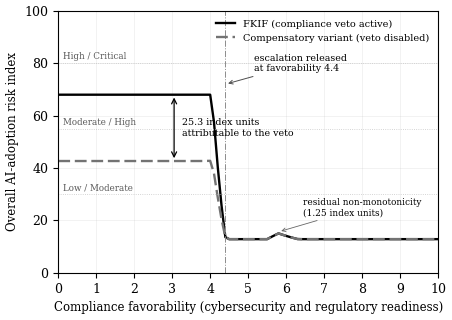

veto contribution at low compliance: 25.33 index units; escalation released at favorability 4.4


In [22]:
import os
os.makedirs('figures', exist_ok=True)
plt.rcParams.update({'font.family':'serif','font.size':9,'axes.linewidth':0.8,
                     'savefig.bbox':'tight','savefig.pad_inches':0.06})
DPI, TIFF = 600, {'compression':'tiff_lzw'}
fkif_noveto = FKIF(veto=False)

xs    = np.arange(0, 10.05, 0.1)
y_on  = np.array([fkif       ([x if i in (5,6) else 8 for i in range(8)]) for x in xs])
y_off = np.array([fkif_noveto([x if i in (5,6) else 8 for i in range(8)]) for x in xs])

fig, ax = plt.subplots(figsize=(4.9, 3.4))
ax.plot(xs, y_on,  color='black', ls='-',        lw=1.7, label='FKIF (compliance veto active)')
ax.plot(xs, y_off, color='0.45',  ls=(0,(5,2)),  lw=1.7, label='Compensatory variant (veto disabled)')
for b, lab in [(30,'Low / Moderate'), (55,'Moderate / High'), (80,'High / Critical')]:
    ax.axhline(b, color='0.78', lw=0.6, ls=':'); ax.text(0.12, b+1.5, lab, fontsize=6.3, color='0.35')
i = int(np.argmax(np.abs(y_on-y_off) < 1e-9))
ax.axvline(xs[i], color='0.55', lw=0.7, ls='-.')
ax.annotate(f'escalation released\nat favorability {xs[i]:.1f}', xy=(xs[i],72), xytext=(5.15,80),
            fontsize=6.8, va='center', arrowprops=dict(arrowstyle='->', lw=0.7, color='0.3'))
ax.annotate('', xy=(3.05,y_on[30]), xytext=(3.05,y_off[30]),
            arrowprops=dict(arrowstyle='<->', lw=0.9, color='black'))
ax.text(3.25, (y_on[30]+y_off[30])/2, f'{y_on[30]-y_off[30]:.1f} index units\nattributable to the veto',
        fontsize=6.8, va='center')
j = int(np.argmax(y_on[45:75])) + 45
ax.annotate('residual non-monotonicity\n(1.25 index units)', xy=(xs[j], y_on[j]+0.6), xytext=(6.45,25),
            fontsize=6.4, va='center', arrowprops=dict(arrowstyle='->', lw=0.6, color='0.4'))
ax.set_xlabel('Compliance favorability (cybersecurity and regulatory readiness)', fontsize=8.5)
ax.set_ylabel('Overall AI-adoption risk index', fontsize=8.5)
ax.set_xlim(0,10); ax.set_ylim(0,100); ax.set_xticks(range(0,11))
ax.legend(loc='upper right', fontsize=7, frameon=False); ax.grid(alpha=0.22, lw=0.5); ax.set_axisbelow(True)
fig.savefig('figures/Figure1.tif', dpi=DPI, pil_kwargs=TIFF); plt.show()
print(f"veto contribution at low compliance: {y_on[30]-y_off[30]:.2f} index units; "
      f"escalation released at favorability {xs[i]:.1f}")

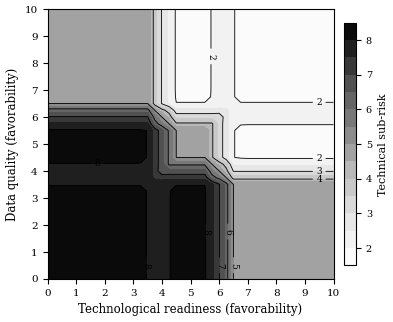

In [23]:
# Figure 2 — control surface as a greyscale contour plot (a 3-D surface is unreadable at 5x8 in B&W)
fig, ax = plt.subplots(figsize=(4.5, 3.5))
X, Y = np.meshgrid(gx, gx)
cf = ax.contourf(X, Y, Z, levels=np.arange(1.5, 8.51, 0.5), cmap='Greys')
cl = ax.contour (X, Y, Z, levels=np.arange(2, 8.51, 1.0), colors='black', linewidths=0.6)
ax.clabel(cl, inline=True, fontsize=6.5, fmt='%.0f')
cb = fig.colorbar(cf, ax=ax, shrink=0.9, pad=0.03, ticks=np.arange(2, 8.1, 1))
cb.set_label('Technical sub-risk', fontsize=8); cb.ax.tick_params(labelsize=7)
ax.set_xlabel('Technological readiness (favorability)', fontsize=8.5)
ax.set_ylabel('Data quality (favorability)', fontsize=8.5)
ax.set_xticks(range(0,11)); ax.set_yticks(range(0,11)); ax.tick_params(labelsize=7.5)
fig.savefig('figures/Figure2.tif', dpi=DPI, pil_kwargs=TIFF); plt.show()

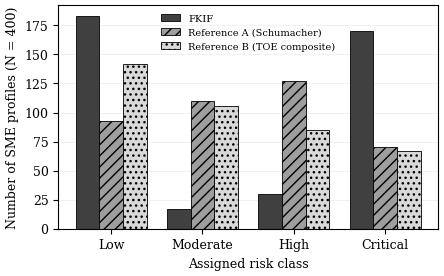

Figure1.tif  2701x1906 px  (600.0, 600.0) dpi  mode=RGBA
Figure2.tif  2358x1935 px  (600.0, 600.0) dpi  mode=RGBA
Figure3.tif  2658x1651 px  (600.0, 600.0) dpi  mode=RGBA


In [24]:
# Figure 3 — class marginals, the mechanism behind the low unweighted kappa
fig, ax = plt.subplots(figsize=(4.9, 2.9))
w_bar, idx = 0.26, np.arange(4)
series = [('FKIF', MARGINALS['FKIF'].values, '', '0.25'),
          ('Reference A (Schumacher)', MARGINALS['Ref A'].values, '///', '0.62'),
          ('Reference B (TOE composite)', MARGINALS['Ref B'].values, '...', '0.85')]
for off, (lab, vals, hatch, col) in zip([-w_bar, 0, w_bar], series):
    ax.bar(idx+off, vals, w_bar, label=lab, color=col, edgecolor='black', lw=0.6, hatch=hatch)
ax.set_xticks(idx); ax.set_xticklabels(LABELS)
ax.set_ylabel('Number of SME profiles (N = 400)'); ax.set_xlabel('Assigned risk class')
ax.legend(fontsize=7, frameon=False); ax.grid(axis='y', alpha=0.25, lw=0.5); ax.set_axisbelow(True)
fig.savefig('figures/Figure3.tif', dpi=DPI, pil_kwargs=TIFF); plt.show()

from PIL import Image
for f in ['Figure1','Figure2','Figure3']:
    im = Image.open(f'figures/{f}.tif')
    print(f"{f}.tif  {im.size[0]}x{im.size[1]} px  {im.info.get('dpi')} dpi  mode={im.mode}")

## Stage 11 — Export every table

Writes each paper table to CSV so the manuscript and the repository cannot drift apart.

In [25]:
for name, df in [('Table2_rule_base', TABLE2), ('Table3_anchors_archetypes', TABLE3),
                 ('Table4_monotonicity', TABLE4), ('Table5_convergent_validity', TABLE5),
                 ('Table6_confusion_matrix', TABLE6), ('Table7_sensitivity', TABLE7),
                 ('class_marginals', MARGINALS)]:
    df.to_csv(f'{name}.csv', index=(name in ('Table6_confusion_matrix','class_marginals')))
    print("wrote", f'{name}.csv')
print("\nAll paper tables and figures regenerated.")

wrote Table2_rule_base.csv
wrote Table3_anchors_archetypes.csv
wrote Table4_monotonicity.csv
wrote Table5_convergent_validity.csv
wrote Table6_confusion_matrix.csv
wrote Table7_sensitivity.csv
wrote class_marginals.csv

All paper tables and figures regenerated.


In [26]:
from google.colab import files
import shutil, os, glob

os.makedirs('fkif_outputs/figures', exist_ok=True)
for f in glob.glob('figures/*.tif'):
    shutil.copy(f, 'fkif_outputs/figures/')
for f in glob.glob('*.csv'):
    shutil.copy(f, 'fkif_outputs/')

shutil.make_archive('fkif_outputs', 'zip', 'fkif_outputs')
print(os.path.getsize('fkif_outputs.zip'), 'bytes')
files.download('fkif_outputs.zip')

1511570 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
!git clone https://github.com/LoveleenGaur/FKIF_automotive_SME_risk.git repo
!cp -r figures repo/figures
!cp *.csv repo/
%cd repo
!git config user.email "gaurloveleen@yahoo.com"
!git config user.name "Loveleen Gaur"
!git add -A && git commit -m "Revised pipeline: rule schema, monotonicity analysis, sensitivity, four references"
!git push https://<TOKEN>@github.com/LoveleenGaur/FKIF_automotive_SME_risk.git main

Cloning into 'repo'...
remote: Enumerating objects: 89, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 89 (delta 29), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (89/89), 9.82 MiB | 16.14 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/repo
[main b7fc5b3] Revised pipeline: rule schema, monotonicity analysis, sensitivity, four references
 10 files changed, 59 insertions(+)
 create mode 100644 Table2_rule_base.csv
 create mode 100644 Table3_anchors_archetypes.csv
 create mode 100644 Table4_monotonicity.csv
 create mode 100644 Table5_convergent_validity.csv
 create mode 100644 Table6_confusion_matrix.csv
 create mode 100644 Table7_sensitivity.csv
 create mode 100644 class_marginals.csv
 create mode 100644 figures/Figure1.tif
 create mode 100644 figures/Figure2.tif
 create mode 100644 figures/Figure3.tif
/bin/bash: line 1: TOKEN: No such file or directory


In [28]:
rows = []
for label, kw in [('veto active (baseline)', {}), ('veto disabled', dict(veto=False))]:
    v  = FV if not kw else aggregate_only(SUB, **kw)
    vb = np.array([band(x) for x in v])
    rows.append({'Variant': label,
        'rho vs Ref A': round(spearmanr(v, np.array([ORDER[x] for x in rs])).statistic, 3),
        'rho vs Ref B': round(spearmanr(v, np.array([ORDER[x] for x in rt])).statistic, 3),
        'quad kappa A': round(cohen_kappa_score(vb, rs, labels=LABELS, weights='quadratic'), 3),
        'quad kappa B': round(cohen_kappa_score(vb, rt, labels=LABELS, weights='quadratic'), 3)})
ABLATION = pd.DataFrame(rows)
print('VETO ABLATION (cited in the paper, subsection: On exact-class agreement)')
print(ABLATION.to_string(index=False))

VETO ABLATION (cited in the paper, subsection: On exact-class agreement)
               Variant  rho vs Ref A  rho vs Ref B  quad kappa A  quad kappa B
veto active (baseline)         0.886         0.889         0.801         0.778
         veto disabled         0.893         0.903         0.827         0.837


In [29]:
!wget -q https://raw.githubusercontent.com/LoveleenGaur/FKIF_automotive_SME_risk/main/fkif.py

from fkif import FKIF
m = FKIF()
for v, expected in [([8]*8, 12.83), ([5]*8, 42.67), ([2]*8, 91.62)]:
    assert abs(m.index(v) - expected) < 0.01, f"mismatch at {v}"
print("fkif.py matches the published anchors")

fkif.py matches the published anchors
